<a href="https://colab.research.google.com/github/joud-alshnoun/Hyperspectral-image-classification/blob/main/DeepLearning_Final_proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Libraries**

In [4]:
import os, zipfile, glob, warnings, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, f1_score
import timm

warnings.filterwarnings('ignore')

# **Data**

In [5]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", DEVICE)

Device: cuda


In [6]:
ZIP_PATH = '/content/beyond-visible-spectrum-ai-for-agriculture-2026.zip'
DATA_DIR = '/content/data'
os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(os.path.join(DATA_DIR, 'Kaggle_Prepared')):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(DATA_DIR)

ROOT = os.path.join(DATA_DIR, 'Kaggle_Prepared')
TRAIN_HS = os.path.join(ROOT, 'train', 'HS')
TRAIN_MS = os.path.join(ROOT, 'train', 'MS')

LABEL_MAP = {'Health': 0, 'Rust': 1, 'Other': 2}
LABEL_NAMES = ['Healthy', 'Rust', 'Other']

def label_from_filename(fname):
    base = os.path.basename(fname)
    for k,v in LABEL_MAP.items():
        if base.startswith(k):
            return v
    return -1

# **DataFrame**

In [7]:
hs_files = sorted(glob.glob(TRAIN_HS + "/*.tif"))
ms_files = sorted(glob.glob(TRAIN_MS + "/*.tif"))

hs_dict = {os.path.basename(f): f for f in hs_files}
ms_dict = {os.path.basename(f): f for f in ms_files}

records = []
for name, hs_path in hs_dict.items():
    if name in ms_dict:
        records.append({
            "filename": name,
            "hs_path": hs_path,
            "ms_path": ms_dict[name],
            "label": label_from_filename(name)
        })

df = pd.DataFrame(records)
print("Samples:", len(df))

Samples: 600


# **PCA** **Training**

In [8]:
N_COMPONENTS = 50
UINT16_MAX = 65535.0

print("Training PCA...")

pca_data = []

for _, row in df.sample(min(300, len(df)), random_state=SEED).iterrows():
    try:
        with rasterio.open(row['hs_path']) as src:
            img = src.read().astype(np.float32) / UINT16_MAX
            img = img[:125]

            B,H,W = img.shape
            pca_data.append(img.reshape(B, -1).T)
    except:
        continue

pca_matrix = np.vstack(pca_data)

pca_model = PCA(n_components=N_COMPONENTS, random_state=SEED)
pca_model.fit(pca_matrix)

print("PCA Ready")

Training PCA...
PCA Ready


# **DataSet**

In [9]:
IMG_SIZE = 64

class CropDataset(Dataset):
    def __init__(self, df, pca, augment=False):
        self.df = df.reset_index(drop=True)
        self.pca = pca
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def resize(self, x):
        x = x.transpose(1,2,0)
        x = cv2.resize(x, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC)
        return x.transpose(2,0,1)

    def apply_pca(self, img):
        B,H,W = img.shape
        pixels = img.reshape(B,-1).T
        reduced = self.pca.transform(pixels)
        return reduced.T.reshape(-1,H,W)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        with rasterio.open(row.hs_path) as src:
            hs = src.read().astype(np.float32)/UINT16_MAX
            hs = hs[:125]

        with rasterio.open(row.ms_path) as src:
            ms = src.read().astype(np.float32)/UINT16_MAX

        hs = self.apply_pca(hs)

        hs = self.resize(hs)
        ms = self.resize(ms)

        x = np.concatenate([hs, ms], axis=0)

        # normalize
        x = (x - x.mean()) / (x.std() + 1e-8)

        # augmentation
        if self.augment:
            if np.random.rand() < 0.5:
                x = np.flip(x,1).copy()
            if np.random.rand() < 0.5:
                x = np.flip(x,2).copy()
            if np.random.rand() < 0.3:
                x += np.random.normal(0,0.02,x.shape)

        return torch.tensor(x,dtype=torch.float32), torch.tensor(row.label,dtype=torch.long)

# **Model (Fusion)**

In [10]:
IN_CH = 55
NUM_CLASSES = 3

class SpectralBranch(nn.Module):
    def __init__(self, in_ch, out=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64,128,3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128,out),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

    def forward(self,x):
        return self.net(x)

class FusionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hs = SpectralBranch(50)
        self.ms = SpectralBranch(5)

        self.gate = nn.Sequential(
            nn.Linear(512,2),
            nn.Softmax(dim=1)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128,3)
        )

    def forward(self,x):
        h = self.hs(x[:,:50])
        m = self.ms(x[:,50:])

        g = self.gate(torch.cat([h,m],dim=1))

        fused = g[:,0:1]*h + g[:,1:2]*m
        return self.classifier(fused)

# **Loss**

In [11]:
criterion = nn.CrossEntropyLoss()

# **Training**

In [12]:
from torch.cuda.amp import autocast, GradScaler

def train(model, train_df, val_df, pca, epochs=50, bs=32):

    train_ds = CropDataset(train_df,pca,True)
    val_ds   = CropDataset(val_df,pca,False)

    labels = train_df['label'].values
    class_count = np.bincount(labels)
    weights = 1.0/class_count[labels]
    sampler = WeightedRandomSampler(weights,len(weights))

    train_loader = DataLoader(train_ds,batch_size=bs,sampler=sampler)
    val_loader = DataLoader(val_ds,batch_size=bs,shuffle=False)

    opt = torch.optim.AdamW(model.parameters(),lr=3e-4)
    scaler = GradScaler()

    best, best_state = 1e9, None

    for ep in range(epochs):
        model.train()
        for x,y in train_loader:
            x,y = x.to(DEVICE),y.to(DEVICE)

            opt.zero_grad()
            with autocast():
                loss = criterion(model(x),y)

            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(DEVICE),y.to(DEVICE)
                val_loss += criterion(model(x),y).item()

        val_loss /= len(val_loader)

        if val_loss < best:
            best = val_loss
            best_state = {k:v.clone() for k,v in model.state_dict().items()}

        print(f"Epoch {ep+1} | Val Loss {val_loss:.4f}")

    return best_state

# **Cross Validation**

In [13]:
skf = StratifiedKFold(n_splits=3,shuffle=True,random_state=SEED)

model = FusionNet().to(DEVICE)

all_preds, all_labels = [], []

for f,(tr,vl) in enumerate(skf.split(df,df.label)):
    print("Fold",f+1)

    state = train(model,df.iloc[tr],df.iloc[vl],pca_model)

    model.load_state_dict(state)
    model.eval()

    val_ds = CropDataset(df.iloc[vl],pca_model,False)
    val_ld = DataLoader(val_ds,batch_size=32)

    with torch.no_grad():
        for x,y in val_ld:
            x = x.to(DEVICE)

            pred = model(x).argmax(1).cpu().numpy()

            all_preds.extend(pred)
            all_labels.extend(y.numpy())

Fold 1
Epoch 1 | Val Loss 1.0102
Epoch 2 | Val Loss 0.8789
Epoch 3 | Val Loss 0.8142
Epoch 4 | Val Loss 0.7692
Epoch 5 | Val Loss 0.7902
Epoch 6 | Val Loss 0.7684
Epoch 7 | Val Loss 0.7553
Epoch 8 | Val Loss 0.7340
Epoch 9 | Val Loss 0.7353
Epoch 10 | Val Loss 0.7440
Epoch 11 | Val Loss 0.7555
Epoch 12 | Val Loss 0.7074
Epoch 13 | Val Loss 0.7509
Epoch 14 | Val Loss 0.7360
Epoch 15 | Val Loss 0.7359
Epoch 16 | Val Loss 0.7333
Epoch 17 | Val Loss 0.7229
Epoch 18 | Val Loss 0.6991
Epoch 19 | Val Loss 0.6601
Epoch 20 | Val Loss 0.6738
Epoch 21 | Val Loss 0.6747
Epoch 22 | Val Loss 0.7237
Epoch 23 | Val Loss 0.7398
Epoch 24 | Val Loss 0.6762
Epoch 25 | Val Loss 0.6804
Epoch 26 | Val Loss 0.7209
Epoch 27 | Val Loss 0.6823
Epoch 28 | Val Loss 0.7240
Epoch 29 | Val Loss 0.7213
Epoch 30 | Val Loss 0.6614
Epoch 31 | Val Loss 0.6847
Epoch 32 | Val Loss 0.6823
Epoch 33 | Val Loss 0.7157
Epoch 34 | Val Loss 0.7208
Epoch 35 | Val Loss 0.6880
Epoch 36 | Val Loss 0.7425
Epoch 37 | Val Loss 0.7072
Epo

# **Results**

In [14]:
print(classification_report(all_labels,all_preds,target_names=LABEL_NAMES))

print("Macro F1:",
      f1_score(all_labels,all_preds,average='macro'))

              precision    recall  f1-score   support

     Healthy       0.67      0.57      0.62       200
        Rust       0.71      0.82      0.76       200
       Other       0.85      0.82      0.84       200

    accuracy                           0.74       600
   macro avg       0.74      0.74      0.74       600
weighted avg       0.74      0.74      0.74       600

Macro F1: 0.7387372284211976


              precision    recall  f1-score   support

     Healthy       0.67      0.57      0.62       200
        Rust       0.71      0.82      0.76       200
       Other       0.85      0.82      0.84       200

    accuracy                           0.74       600
   macro avg       0.74      0.74      0.74       600
weighted avg       0.74      0.74      0.74       600

Macro F1: 0.7387372284211976


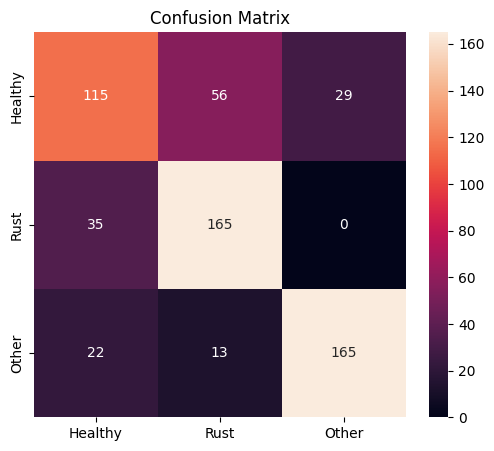

In [17]:
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES))
print("Macro F1:", f1_score(all_labels, all_preds, average='macro'))

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES)
plt.title("Confusion Matrix")
plt.show()